<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/climas_brasil_camargo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação Climática de Camargo (1991) mod. Maluf (2000) para o Brasil
Mapeamento, em escala municipal, da classificação climática de Camargo (classe térmica, classe hídrica e classificação completa) e das variáveis de balanço hídrico associadas, a partir das normais climatológicas 1991-2020 (TerraClimate).
___

## 1. Bibliotecas
___

In [1]:
# =========================================================
# BIBLIOTECAS NECESSÁRIAS
# =========================================================
# geobr/geopandas   -> malha municipal e estadual do IBGE
# cartopy           -> projeção cartográfica e feições de referência (costa, fronteiras)
# matplotlib        -> geração das figuras
# matplotlib-scalebar-> barra de escala automática nos mapas
# rasterio/elevation -> dependências do geobr para leitura de dados geoespaciais
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar --quiet

import numpy as np
import pandas as pd
import unicodedata
import warnings

import geopandas as gpd
import geobr
from geobr import read_municipality

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import DownloadWarning

warnings.filterwarnings("ignore", category=DownloadWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.9 MB/s eta 0:00:00


## 2. Carregar o CSV de classificação
___

In [2]:
# Tabela com a classificação de Camargo já calculada por município
# (uma linha por município, identificado pelo código IBGE `code_muni`)
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/camargo_municipios_preenchido.csv"
df_camargo = pd.read_csv(url, sep=",")
df_camargo

,code_muni,name_muni,abbrev_state,camargo_completo,cm_termico,cm_termico_codigo,cm_hidrico,cm_hidrico_codigo,cm_letra_seca,def_anual_mm,excedente_anual_mm,temp_anual_c,temp_mes_mais_frio_c,preenchido_por_vizinho
0,1100015.0,Alta Floresta d'Oeste,RO,TR-MOi,TR,7.0,MO,4.0,i,212.139999,557.433331,25.139166,23.733334,False
1,1100023.0,Ariquemes,RO,TR-MOi,TR,7.0,MO,4.0,i,152.420000,1189.166675,25.682638,24.898333,False
2,1100031.0,Cabixi,RO,TR-MOi,TR,7.0,MO,4.0,i,238.443335,600.599997,25.445833,23.531666,False
3,1100049.0,Cacoal,RO,TR-MOi,TR,7.0,MO,4.0,i,195.323335,997.233310,24.789722,23.655000,False
4,1100056.0,Cerejeiras,RO,TR-MOi,TR,7.0,MO,4.0,i,260.886671,518.200001,25.460278,23.668333,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5565,5222005.0,Vianópolis,GO,ST-MOi,ST,6.0,MO,4.0,i,418.139998,645.733327,21.919445,19.448334,False
5566,5222054.0,Vicentinópolis,GO,TR-MOi,TR,7.0,MO,4.0,i,444.010000,635.700009,24.239584,21.793333,False
5567,5222203.0,Vila Boa,GO,TR-MOi,TR,7.0,MO,4.0,i,519.769995,368.300001,24.911528,22.406666,False
5568,5222302.0,Vila Propício,GO,TR-MOi,TR,7.0,MO,4.0,i,459.106668,548.966671,24.155972,21.713333,False


## 3. Legenda, paleta e utilitários
___

In [3]:
# =========================================================
# LEGENDA E PALETA DE CORES — CAMARGO (1991) MOD. MALUF (2000)
# =========================================================
# a classificação de Camargo combina uma classe térmica e uma classe hídrica;
# cada uma tem seu próprio código, sigla, nome descritivo e cor

# `cm_termico_codigo` (int, 1-8) -> sigla da classe térmica (ex.: 1 -> 'GL')
CM_TERMICO_LABELS = {1:'GL', 2:'FR', 3:'CO', 4:'TE', 5:'STE', 6:'ST', 7:'TR', 8:'EQ'}
CM_TERMICO_NOMES = {
    1:'Gélido', 2:'Frio', 3:'Frio moderado', 4:'Temperado', 5:'Subtemperado',
    6:'Subtropical', 7:'Tropical', 8:'Equatorial'
}
CM_TERMICO_COLORS = {
    1:'#4575b4', 2:'#74add1', 3:'#abd9e9', 4:'#fee08b', 5:'#fdae61', 6:'#f46d43', 7:'#d73027', 8:'#a50026'
}

# `cm_hidrico_codigo` (int, 1-8) -> sigla da classe hídrica (ex.: 1 -> 'DE')
CM_HIDRICO_LABELS = {1:'DE', 2:'AR', 3:'SE', 4:'MO', 5:'SB', 6:'UM', 7:'PU', 8:'SU'}
CM_HIDRICO_NOMES = {
    1:'Desértico', 2:'Árido', 3:'Seco', 4:'Monçônico', 5:'Subúmido', 6:'Úmido',
    7:'Superúmido', 8:'Extremamente úmido'
}
CM_HIDRICO_COLORS = {
    1:'#8c510a', 2:'#d8b365', 3:'#f6e8c3', 4:'#fee08b', 5:'#c7eae5', 6:'#5ab4ac', 7:'#01807a', 8:'#003c30'
}


def normalize(s):
    """Remove acentos e caracteres especiais de uma string, retornando-a em
    maiúsculas e sem espaços nas extremidades.

    Usada para padronizar nomes de município/estado antes de eventuais
    comparações ou junções (merge) feitas por nome, em vez de código IBGE.

    Parameters
    ----------
    s : str
        Texto de entrada (ex.: nome de município).

    Returns
    -------
    str
        Texto normalizado (sem acentos, em maiúsculas).
    """
    if pd.isna(s):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', str(s)) if not unicodedata.combining(c)).upper().strip()


# tabela auxiliar nome-do-estado -> sigla, usada em conjunto com `normalize()`
# quando a junção dos dados precisa ser feita pelo nome do estado
STATE_ABBR = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPA':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARA':'CE',
    'DISTRITO FEDERAL':'DF','ESPIRITO SANTO':'ES','GOIAS':'GO','MARANHAO':'MA','MATO GROSSO':'MT',
    'MATO GROSSO DO SUL':'MS','MINAS GERAIS':'MG','PARA':'PA','PARAIBA':'PB','PARANA':'PR',
    'PERNAMBUCO':'PE','PIAUI':'PI','RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN',
    'RIO GRANDE DO SUL':'RS','RONDONIA':'RO','RORAIMA':'RR','SANTA CATARINA':'SC','SAO PAULO':'SP',
    'SERGIPE':'SE','TOCANTINS':'TO',
}

In [4]:
# Malha municipal e estadual do IBGE (ano-base 2020), reprojetada para WGS84 (EPSG:4326)
municipios_gdf = geobr.read_municipality(code_muni='all', year=2020).to_crs(epsg=4326)
estados_gdf = geobr.read_state(code_state='all', year=2020).to_crs(epsg=4326)
print(f'geobr trouxe {len(municipios_gdf)} municípios e {len(estados_gdf)} estados.')

# ponto representativo interno de cada município (garantidamente dentro do
# polígono, mesmo em formatos côncavos, ao contrário do centroide geométrico)
municipios_gdf['pt_interno'] = municipios_gdf.geometry.representative_point()
municipios_gdf['lon_c'] = municipios_gdf['pt_interno'].x
municipios_gdf['lat_c'] = municipios_gdf['pt_interno'].y
municipios_gdf['municipio_norm'] = municipios_gdf['name_muni'].apply(normalize)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:01<00:00, 10.9MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 42.1MB/s]


geobr trouxe 5570 municípios e 27 estados.


## 4. Funções de plotagem (estilo cartopy padrão)
___

In [5]:
def _base_map(ax, titulo):
    """Configura os elementos-base comuns a todos os mapas: extensão espacial
    (com margem de 5% ao redor do território), continente, fronteiras e linha
    de costa.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Eixo cartográfico já criado com a projeção desejada.
    titulo : str
        Reservado para uso futuro (não altera o eixo diretamente).

    Returns
    -------
    tuple
        (minx, miny, maxx, maxy) — limites geográficos do Brasil, usados
        depois por `_decoracoes` para dimensionar a barra de escala.
    """
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05  # margem de 5% em cada lado
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy


def _decoracoes(ax, minx, miny, maxx, maxy):
    """Adiciona os elementos de acabamento cartográfico ao mapa: limites
    estaduais, grade de coordenadas, seta norte e barra de escala.

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxes
        Eixo cartográfico já com o mapa-base desenhado.
    minx, miny, maxx, maxy : float
        Limites geográficos do território (graus decimais), usados para
        estimar a largura em quilômetros e escolher um valor "redondo"
        para a barra de escala.
    """
    # contorno dos estados, sobreposto aos municípios já coloridos
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)

    # grade de coordenadas (latitude/longitude), sem rótulos no topo/direita
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}

    # seta indicando o norte geográfico, no canto inferior direito
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))

    # barra de escala: converte graus em metros na latitude média do mapa e
    # arredonda para o valor "redondo" mais próximo de 1/4 da largura do mapa,
    # evitando escalas com números quebrados (ex.: "137 km")
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))

In [6]:
def plot_categorico(gdf, coluna_codigo, labels, nomes, colors, titulo, legenda_titulo, savepath=None):
    """Mapa coroplético de uma classificação categórica codificada em números
    inteiros (classe térmica ou classe hídrica de Camargo), com legenda
    trazendo a sigla e o nome descritivo de cada classe presente no mapa.

    Parameters
    ----------
    gdf : geopandas.GeoDataFrame
        Malha municipal já mesclada com a coluna de código da classe.
    coluna_codigo : str
        Nome da coluna com o código inteiro da classe (ex.: 'cm_termico_codigo').
    labels : dict
        Código -> sigla da classe (ex.: `CM_TERMICO_LABELS`).
    nomes : dict
        Código -> nome descritivo da classe (ex.: `CM_TERMICO_NOMES`).
    colors : dict
        Código -> cor hexadecimal da classe (ex.: `CM_TERMICO_COLORS`).
    titulo : str
        Título do mapa.
    legenda_titulo : str
        Título exibido no topo da caixa de legenda.
    savepath : str, opcional
        Caminho do arquivo PNG a ser salvo (600 dpi). Se None, a figura não é salva.
    """
    classes = sorted(gdf[coluna_codigo].dropna().unique().astype(int))

    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)

    # desenha os municípios classe a classe, para garantir cor exata por classe
    for c in classes:
        gdf[gdf[coluna_codigo] == c].plot(ax=ax, color=colors[c], edgecolor='none',
                                           transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)

    # legenda: um retângulo colorido por classe, com sigla e nome descritivo,
    # sem indicar percentuais de ocorrência
    patches = [mpatches.Patch(facecolor=colors[c], edgecolor='black', linewidth=0.4,
                               label=f'{labels[c]} — {nomes[c]}')
               for c in classes]
    ax.legend(handles=patches, title=legenda_titulo, loc='upper right', frameon=True, fontsize=8.5)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

In [7]:
def plot_continua(gdf, coluna, titulo, unidade, cmap_nome, savepath=None):
    """Mapa coroplético de uma variável climática contínua (ex.: deficiência
    hídrica, temperatura), com escala de cores contínua e barra de cores lateral.

    Parameters
    ----------
    gdf : geopandas.GeoDataFrame
        Malha municipal já mesclada com a variável de interesse.
    coluna : str
        Nome da coluna numérica a ser mapeada (ex.: 'def_anual_mm').
    titulo : str
        Título do mapa e rótulo da barra de cores.
    unidade : str
        Unidade de medida, exibida ao lado do título na barra de cores (ex.: 'mm', '°C').
    cmap_nome : str
        Nome de um colormap do matplotlib (ex.: 'YlOrRd', 'RdYlBu_r').
    savepath : str, opcional
        Caminho do arquivo PNG a ser salvo (600 dpi). Se None, a figura não é salva.
    """
    dados = gdf.dropna(subset=[coluna])

    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)

    # limites de cor nos percentis 2%-98%, para que eventuais outliers não
    # "esmaguem" a escala de cores do restante dos municípios
    vmin, vmax = dados[coluna].quantile([0.02, 0.98])
    dados.plot(column=coluna, cmap=cmap_nome, vmin=vmin, vmax=vmax, ax=ax, edgecolor='none',
               transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)

    # barra de cores construída manualmente (ScalarMappable), pois o `plot`
    # do geopandas não expõe diretamente um objeto compatível com `plt.colorbar`
    sm = plt.cm.ScalarMappable(cmap=cmap_nome, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.035, pad=0.02, shrink=0.6)
    cbar.set_label(f'{titulo} ({unidade})', fontsize=10)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

## 5. Merge dos dados com os polígonos
___

In [8]:
# Junta a malha municipal (geometria) com a tabela de classificação (atributos),
# usando o código IBGE do município como chave
gdf_camargo_merged = municipios_gdf.merge(df_camargo, on='code_muni', how='left')
print('Municípios com classe térmica:', gdf_camargo_merged['cm_termico_codigo'].notna().sum(),
      'de', len(gdf_camargo_merged))

Municípios com classe térmica: 5570 de 5570


## 6. Capítulo 1 — Classe térmica de Camargo
___

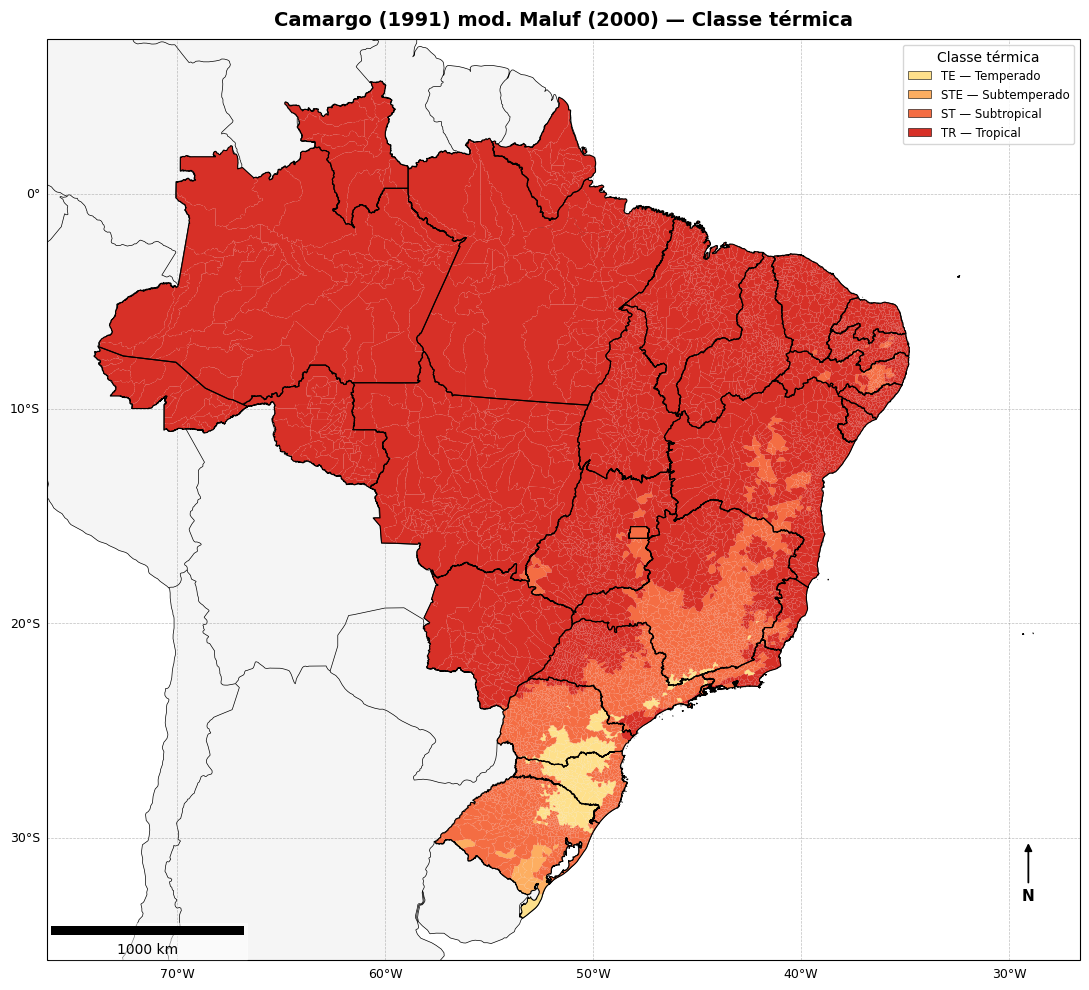

In [16]:
warnings.filterwarnings("ignore")
plot_categorico(gdf_camargo_merged, 'cm_termico_codigo', CM_TERMICO_LABELS, CM_TERMICO_NOMES,
                CM_TERMICO_COLORS, 'Camargo (1991) mod. Maluf (2000) — Classe térmica',
                'Classe térmica', 'camargo_termico.png')

## 7. Capítulo 2 — Classe hídrica de Camargo
___

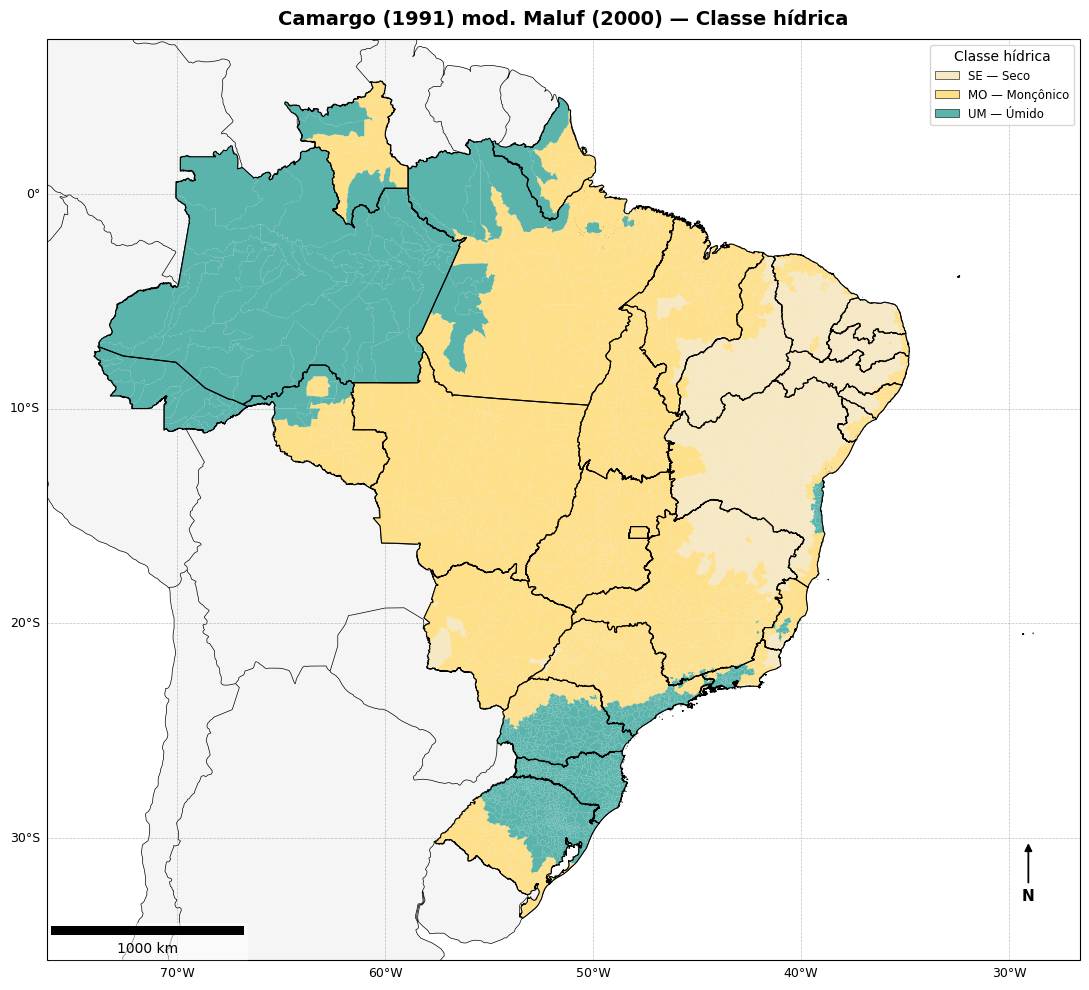

In [17]:
warnings.filterwarnings("ignore")
plot_categorico(gdf_camargo_merged, 'cm_hidrico_codigo', CM_HIDRICO_LABELS, CM_HIDRICO_NOMES,
                CM_HIDRICO_COLORS, 'Camargo (1991) mod. Maluf (2000) — Classe hídrica',
                'Classe hídrica', 'camargo_hidrico.png')

## 8. Capítulo 3 — Balanço hídrico
___

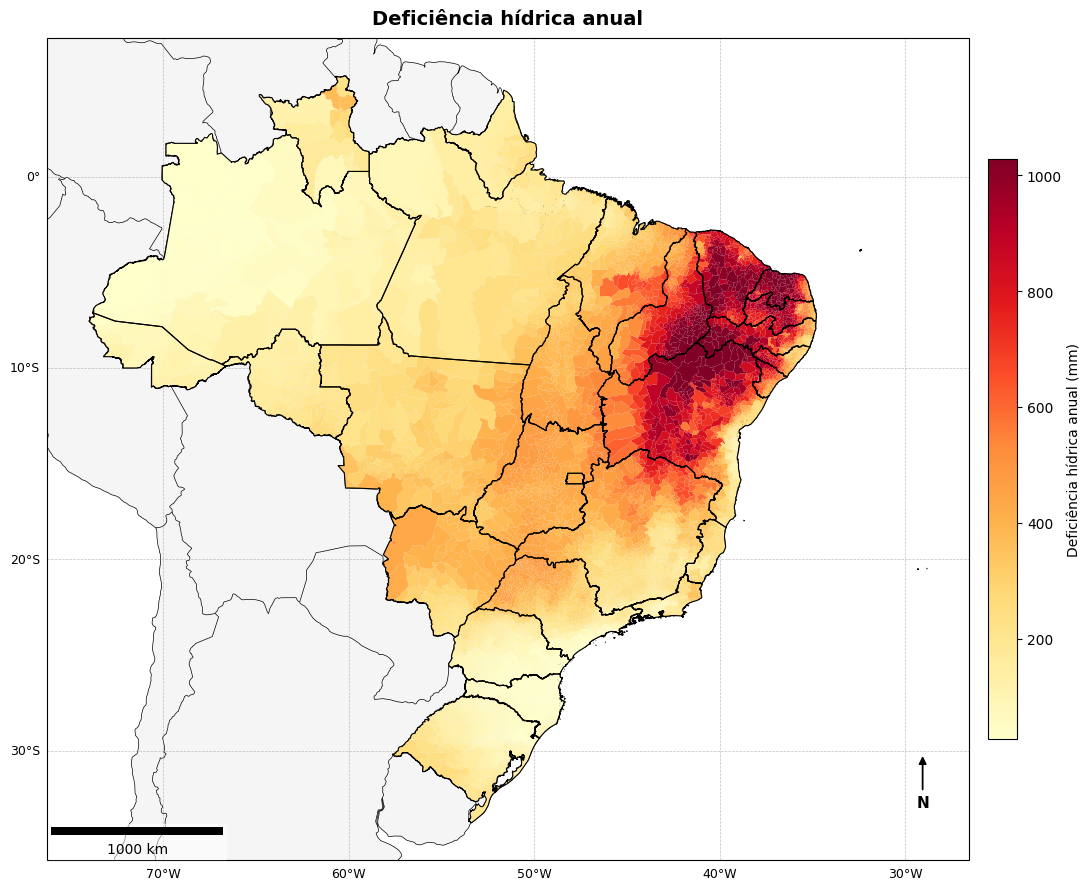

In [18]:
warnings.filterwarnings("ignore")
plot_continua(gdf_camargo_merged, 'def_anual_mm', 'Deficiência hídrica anual',
              'mm', 'YlOrRd', 'def_anual.png')

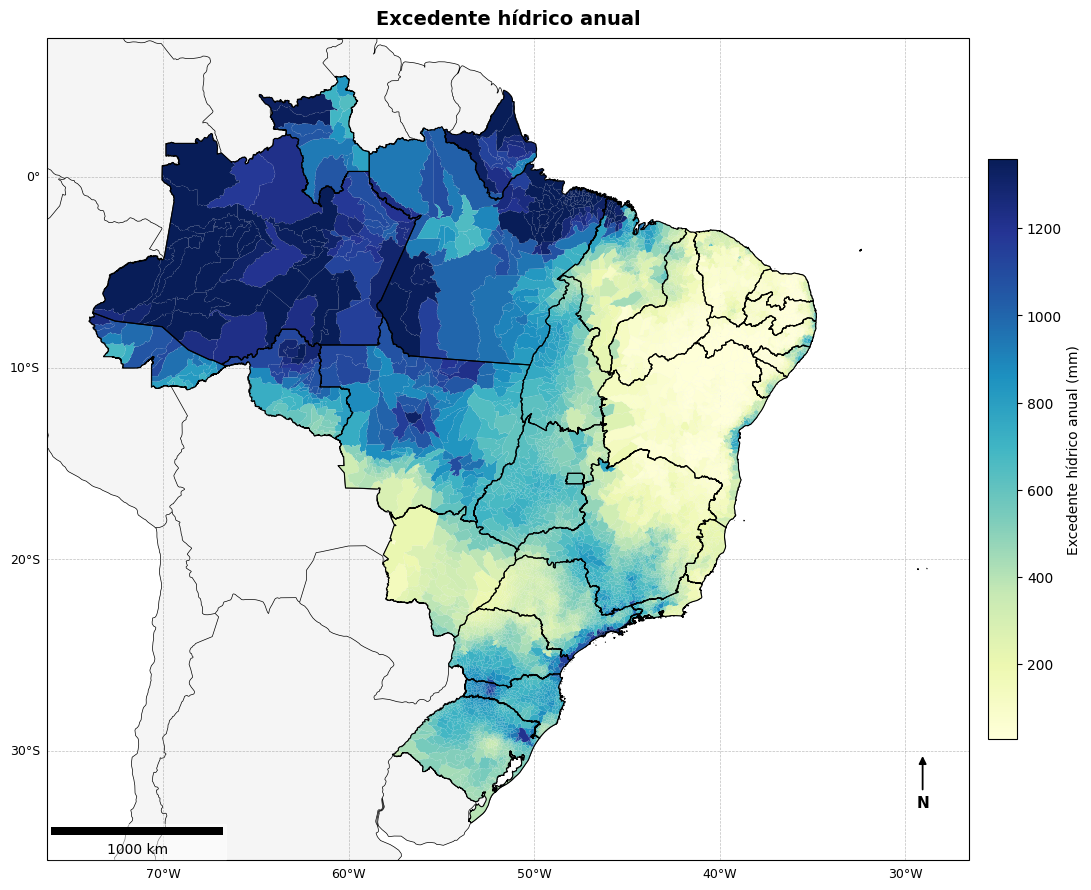

In [19]:
warnings.filterwarnings("ignore")
plot_continua(gdf_camargo_merged, 'excedente_anual_mm', 'Excedente hídrico anual',
              'mm', 'YlGnBu', 'excedente_anual.png')

## 9. Capítulo 4 — Temperatura
___

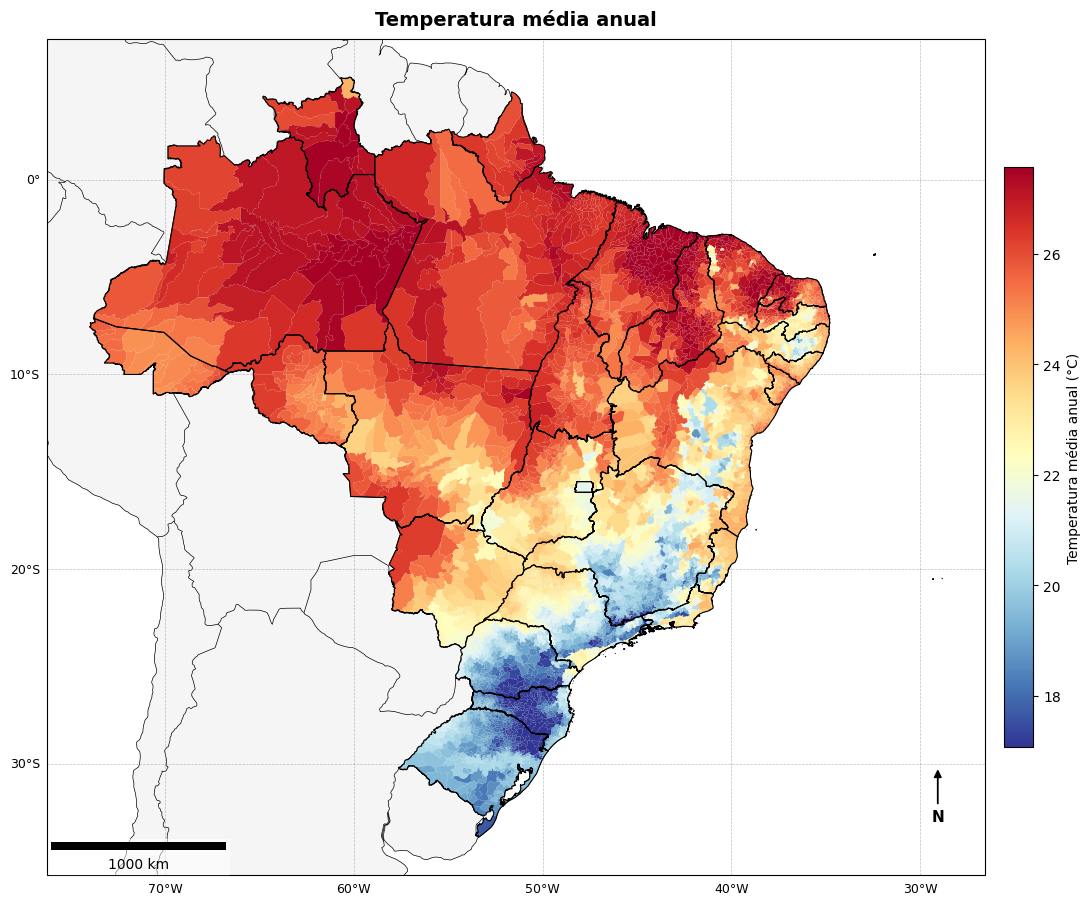

In [20]:
warnings.filterwarnings("ignore")
plot_continua(gdf_camargo_merged, 'temp_anual_c', 'Temperatura média anual',
              '°C', 'RdYlBu_r', 'temp_anual.png')

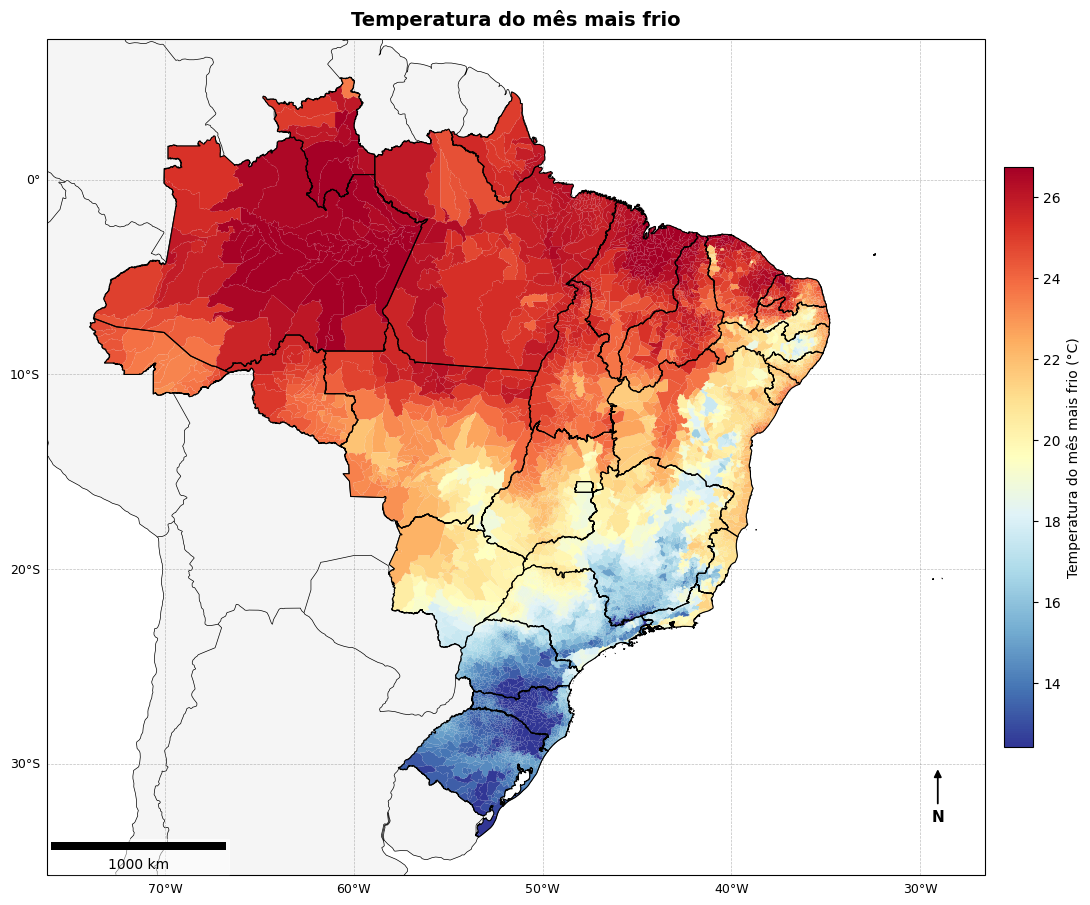

In [22]:
warnings.filterwarnings("ignore")
plot_continua(gdf_camargo_merged, 'temp_mes_mais_frio_c', 'Temperatura do mês mais frio',
              '°C', 'RdYlBu_r', 'temp_mes_frio.png')

## 10. Capítulo 5 — Camargo completo (térmico + hídrico + estação seca)
___

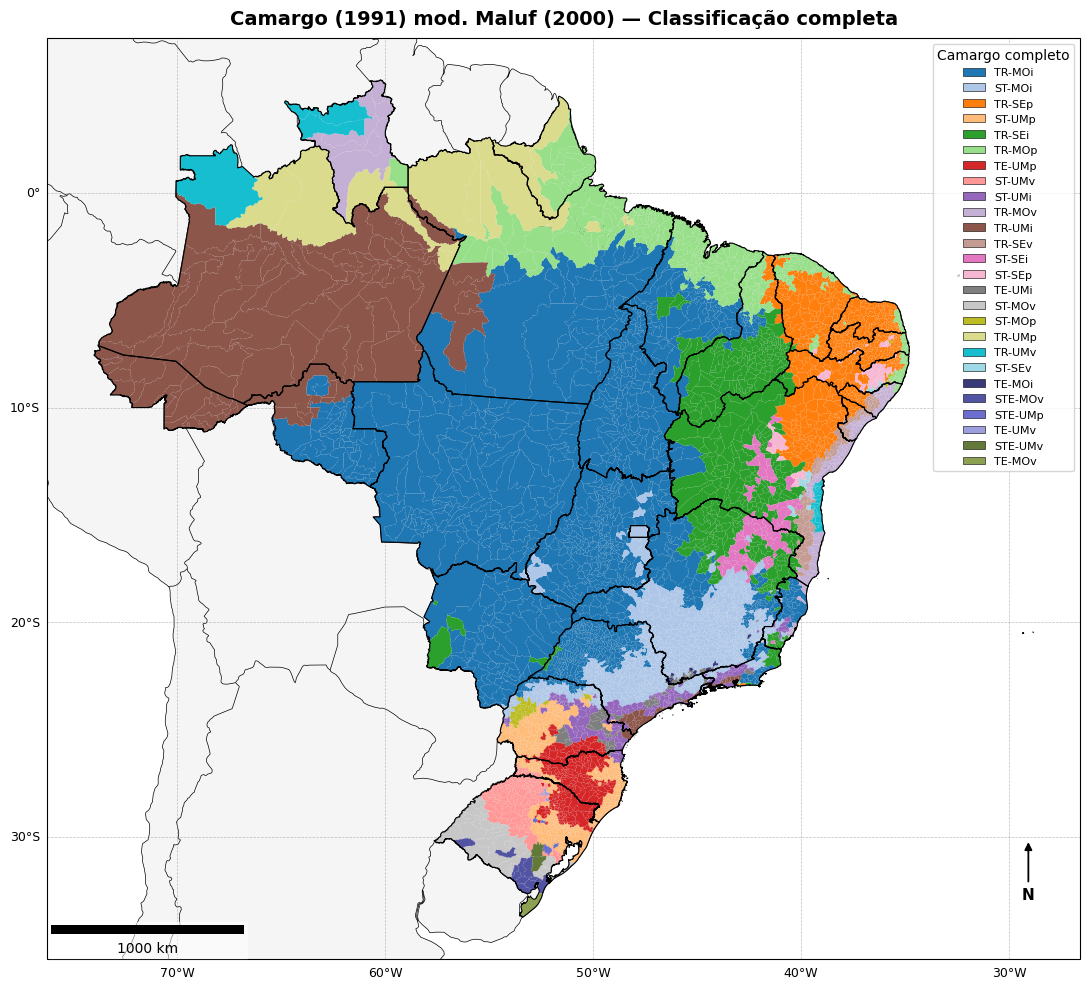

In [21]:
def plot_camargo_completo(gdf, coluna='camargo_completo', savepath='camargo_completo.png'):
    """Mapa coroplético da classificação completa de Camargo (sigla combinando
    classe térmica, classe hídrica e estação seca, ex.: 'TR-MOi'), com uma cor
    distinta por combinação observada nos dados.

    Como o número de combinações não é fixo a priori (depende de quais códigos
    aparecem nos dados), as cores são geradas dinamicamente a partir de paletas
    categóricas do matplotlib, em vez de um dicionário fixo como em
    `plot_categorico`.

    Parameters
    ----------
    gdf : geopandas.GeoDataFrame
        Malha municipal já mesclada com a coluna de classificação completa.
    coluna : str, opcional
        Nome da coluna textual com o código completo. Default: 'camargo_completo'.
    savepath : str, opcional
        Caminho do arquivo PNG a ser salvo (600 dpi).
    """
    dados = gdf.dropna(subset=[coluna])

    # ordena as classes por frequência (mais comum primeiro), para a legenda
    # ficar organizada da classe mais representativa para a mais rara
    classes = dados[coluna].value_counts().index.tolist()

    # paleta categórica automática (tab20 + tab20b cobrem até 40 classes distintas)
    base_cmap = plt.cm.tab20.colors + plt.cm.tab20b.colors
    cores = {cls: base_cmap[i % len(base_cmap)] for i, cls in enumerate(classes)}

    fig = plt.figure(figsize=(11, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, 'Camargo completo')

    for cls in classes:
        dados[dados[coluna] == cls].plot(ax=ax, color=cores[cls], edgecolor='none',
                                          transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)

    # legenda: um retângulo colorido por classe completa observada,
    # sem indicar percentuais de ocorrência
    patches = [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.4,
                              label=cls)
               for cls in classes]
    ax.legend(handles=patches, title='Camargo completo', loc='upper right',
              frameon=True, fontsize=8, ncol=1)

    ax.set_title('Camargo (1991) mod. Maluf (2000) — Classificação completa',
                 fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

warnings.filterwarnings("ignore")
plot_camargo_completo(gdf_camargo_merged)